In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
import pandas as pd
import json

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [2]:
def count_sign_changes(delta_x):
    signs = np.sign(delta_x)
    sign_changes = np.sum(np.diff(signs) != 0)
    return sign_changes

def is_bifurcation(delta_x_list):
    counts = [count_sign_changes(delta_x) for delta_x in delta_x_list]
    unique_counts = set(counts)
    return len(unique_counts) > 1

def metastability_score(f, df, x_grid, tau):
    distance_to_critical = f(x_grid)**2 + df(x_grid)**2
    normalized_distance = distance_to_critical * tau**2 # between 0 (critical) and 1 (linear dynamics)
    return 1-np.min(normalized_distance) 

In [3]:
json_path = cwd / "5CV_Passive_late.json"
with open(json_path, "r") as f:
    data_5cv = json.load(f)
    results_cv = data_5cv.get("results_cv")
    print("Loaded results_cv:", results_cv)

Loaded results_cv: ['NonLinear1', 'NonLinear1', 'NonLinear1', 'GainModulation', 'GainModulation', 'NonLinear1', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'NonLinear1', 'GainModulation']


# Bifurcation Probability & Metastability Scoring 

### Via Particle Density Estimation for the best model **per participant**

Found existing summary at MeasureNoiseControl/metabifurc_control.csv, containing 17 entries.


Participants:   0%|          | 0/92 [00:00<?, ?it/s]

process_noise = 0.6150, measure_noise = 0.4893, ratio = 0.5561754197793293 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.40986254996617566, 
for a real g4 of 0.35133952641183286.


Tau grid for part 8:   0%|          | 0/21 [00:00<?, ?it/s]

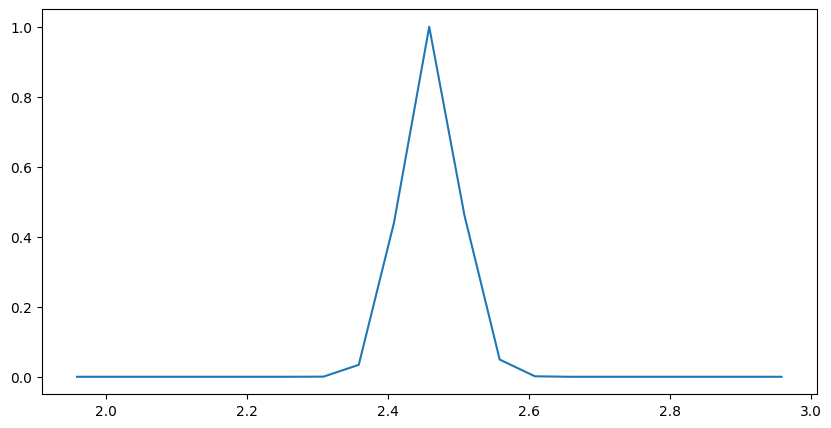

2D Search (Tau) for Part 8: 0it [00:00, ?it/s]

2.358596487981468 is a good enough tau
2.4085964879814683 is a good enough tau
2.458596487981468 is a good enough tau
2.5085964879814684 is a good enough tau
2.558596487981468 is a good enough tau
2.608596487981468 is a good enough tau
process_noise = 0.6150, measure_noise = 0.5545, ratio = 0.6660159818418826 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.36065411622590865, 
for a real g4 of 0.35133952641183286.


Tau grid for part 8:   0%|          | 0/21 [00:00<?, ?it/s]

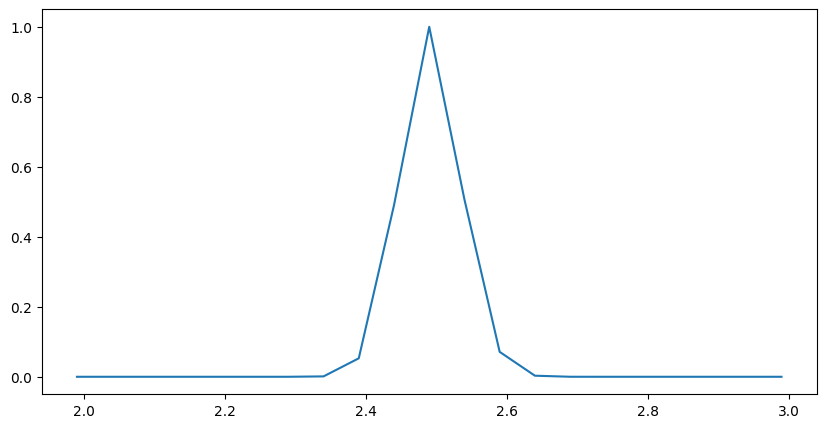

2D Search (Tau) for Part 8: 0it [00:00, ?it/s]

2.339936335685032 is a good enough tau
2.389936335685032 is a good enough tau
2.439936335685032 is a good enough tau
2.489936335685032 is a good enough tau
2.5399363356850317 is a good enough tau
2.589936335685032 is a good enough tau
2.639936335685032 is a good enough tau
process_noise = 0.5409, measure_noise = 0.1298, ratio = 0.8396420085809971 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.46034027403048916, 
for a real g4 of 0.421792539086965.


Tau grid for part 9:   0%|          | 0/21 [00:00<?, ?it/s]

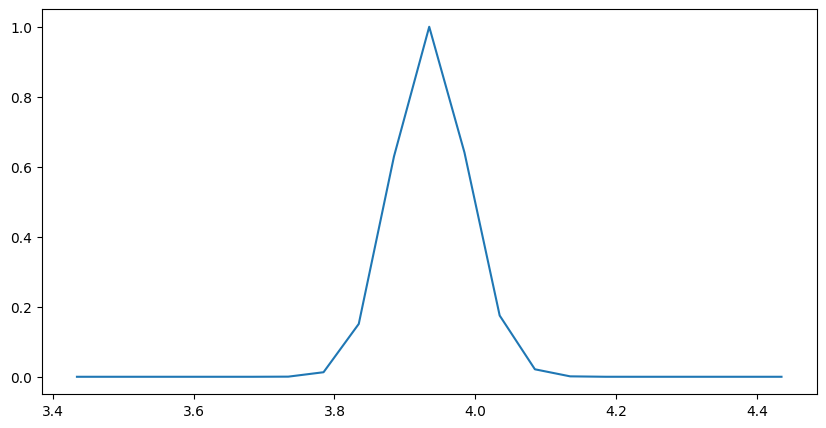

2D Search (Tau) for Part 9: 0it [00:00, ?it/s]

3.7845323652344214 is a good enough tau
3.834532365234421 is a good enough tau
3.8845323652344215 is a good enough tau
3.9345323652344213 is a good enough tau
3.984532365234421 is a good enough tau
4.034532365234421 is a good enough tau
4.084532365234422 is a good enough tau
4.1345323652344215 is a good enough tau
process_noise = 0.5409, measure_noise = 0.3969, ratio = 0.811835645940337 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.4216993972560037, 
for a real g4 of 0.421792539086965.


Tau grid for part 9:   0%|          | 0/21 [00:00<?, ?it/s]

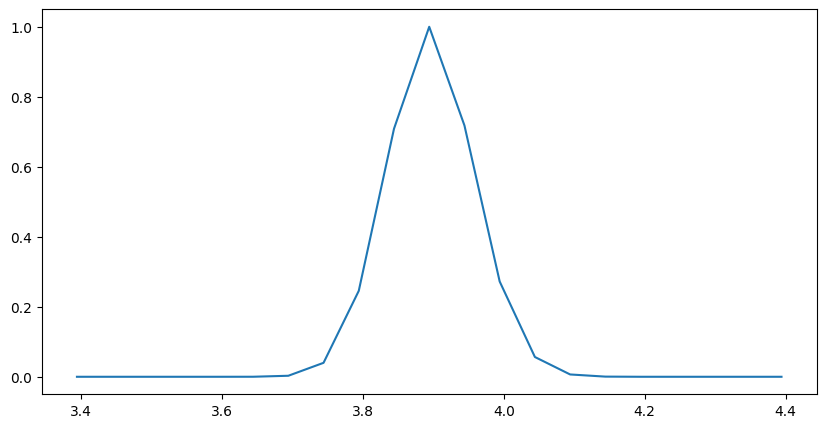

2D Search (Tau) for Part 9: 0it [00:00, ?it/s]

3.694127876965239 is a good enough tau
3.744127876965239 is a good enough tau
3.794127876965239 is a good enough tau
3.844127876965239 is a good enough tau
3.894127876965239 is a good enough tau
3.944127876965239 is a good enough tau
3.994127876965239 is a good enough tau
4.04412787696524 is a good enough tau
4.094127876965239 is a good enough tau
process_noise = 0.6229, measure_noise = 0.6637, ratio = 0.539073045781249 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.44255982992176907, 
for a real g4 of 0.3464740272216743.


Tau grid for part 10:   0%|          | 0/21 [00:00<?, ?it/s]

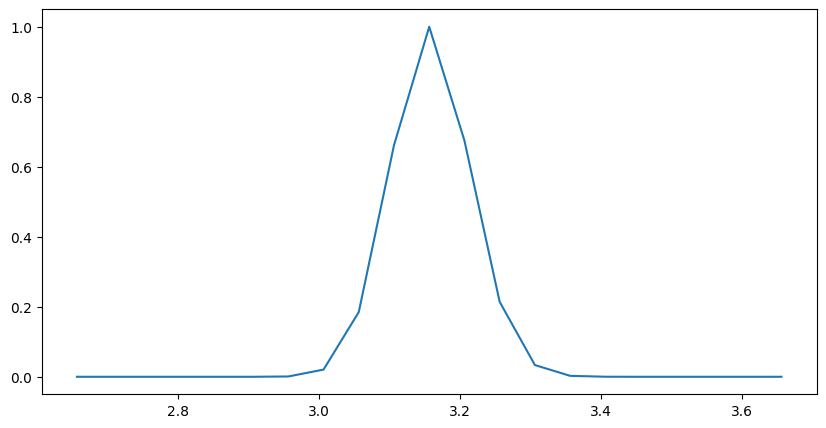

2D Search (Tau) for Part 10: 0it [00:00, ?it/s]

3.006439579284326 is a good enough tau
3.056439579284326 is a good enough tau
3.1064395792843262 is a good enough tau
3.156439579284326 is a good enough tau
3.206439579284326 is a good enough tau
3.256439579284326 is a good enough tau
3.306439579284326 is a good enough tau
3.3564395792843262 is a good enough tau
process_noise = 0.6229, measure_noise = 0.3163, ratio = 0.8858279847648017 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.25550849899755046, 
for a real g4 of 0.3464740272216743.


Tau grid for part 10:   0%|          | 0/21 [00:00<?, ?it/s]

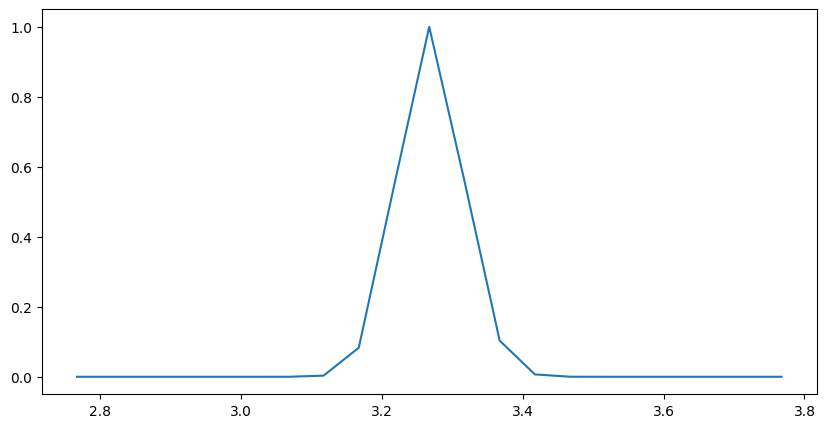

2D Search (Tau) for Part 10: 0it [00:00, ?it/s]

3.1174141308938896 is a good enough tau
3.1674141308938895 is a good enough tau
3.2174141308938897 is a good enough tau
3.2674141308938895 is a good enough tau
3.31741413089389 is a good enough tau
3.3674141308938896 is a good enough tau
3.4174141308938895 is a good enough tau
process_noise = 0.6185, measure_noise = 0.4147, ratio = 0.6339350124573218 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.33593456972765434, 
for a real g4 of 0.3219069314591996.


Tau grid for part 11:   0%|          | 0/21 [00:00<?, ?it/s]

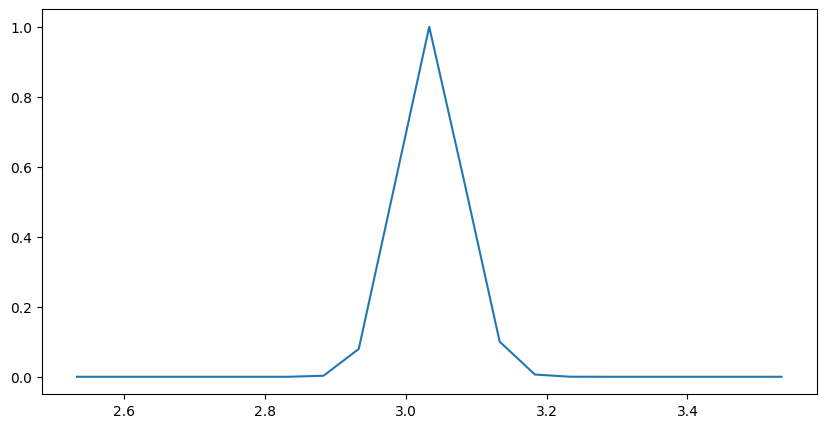

2D Search (Tau) for Part 11: 0it [00:00, ?it/s]

2.883441267751707 is a good enough tau
2.9334412677517068 is a good enough tau
2.983441267751707 is a good enough tau
3.033441267751707 is a good enough tau
3.0834412677517067 is a good enough tau
3.133441267751707 is a good enough tau
3.1834412677517068 is a good enough tau
process_noise = 0.6185, measure_noise = 0.4211, ratio = 0.8019499846487889 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.33353469480324316, 
for a real g4 of 0.3219069314591996.


Tau grid for part 11:   0%|          | 0/21 [00:00<?, ?it/s]

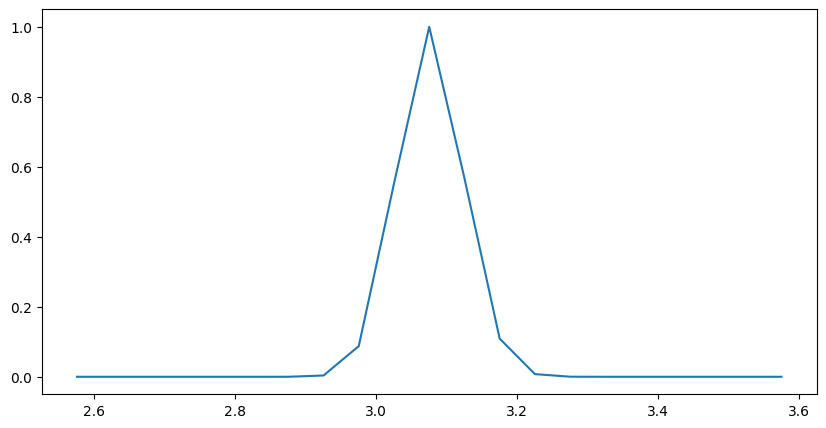

2D Search (Tau) for Part 11: 0it [00:00, ?it/s]

2.925640526711618 is a good enough tau
2.9756405267116177 is a good enough tau
3.025640526711618 is a good enough tau
3.075640526711618 is a good enough tau
3.125640526711618 is a good enough tau
3.175640526711618 is a good enough tau
3.2256405267116177 is a good enough tau
process_noise = 0.5461, measure_noise = 0.4382, ratio = 0.575565707605783 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.35473335558617636, 
for a real g4 of 0.32223846932011335.


Tau grid for part 12:   0%|          | 0/21 [00:00<?, ?it/s]

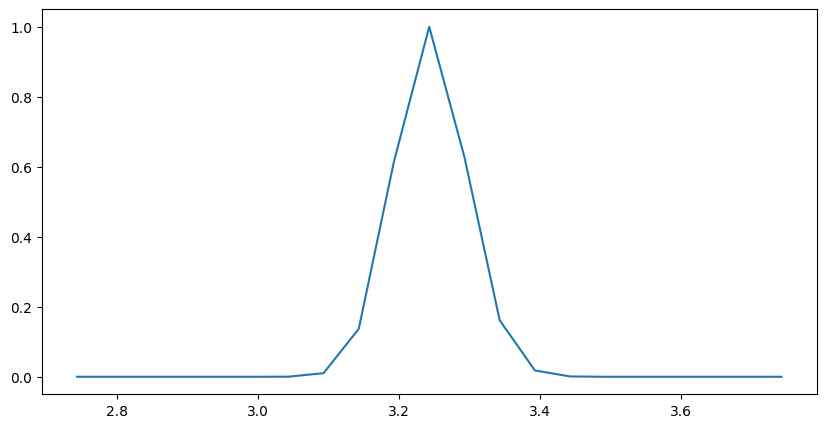

2D Search (Tau) for Part 12: 0it [00:00, ?it/s]

3.0929427501792235 is a good enough tau
3.1429427501792233 is a good enough tau
3.1929427501792236 is a good enough tau
3.2429427501792234 is a good enough tau
3.2929427501792237 is a good enough tau
3.3429427501792235 is a good enough tau
3.3929427501792233 is a good enough tau
process_noise = 0.5461, measure_noise = 0.5250, ratio = 0.6831423885829127 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.3366173843730387, 
for a real g4 of 0.32223846932011335.


Tau grid for part 12:   0%|          | 0/21 [00:00<?, ?it/s]

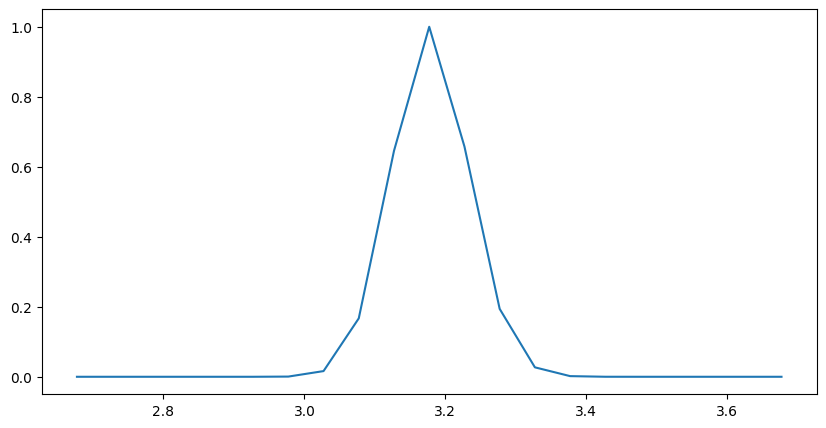

2D Search (Tau) for Part 12: 0it [00:00, ?it/s]

3.0271556877144743 is a good enough tau
3.077155687714474 is a good enough tau
3.1271556877144744 is a good enough tau
3.177155687714474 is a good enough tau
3.2271556877144745 is a good enough tau
3.2771556877144743 is a good enough tau
3.327155687714474 is a good enough tau
3.3771556877144744 is a good enough tau
process_noise = 0.4541, measure_noise = 0.6245, ratio = 0.4800754918566545 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.22267692473511225, 
for a real g4 of 0.2605828109066728.


Tau grid for part 13:   0%|          | 0/21 [00:00<?, ?it/s]

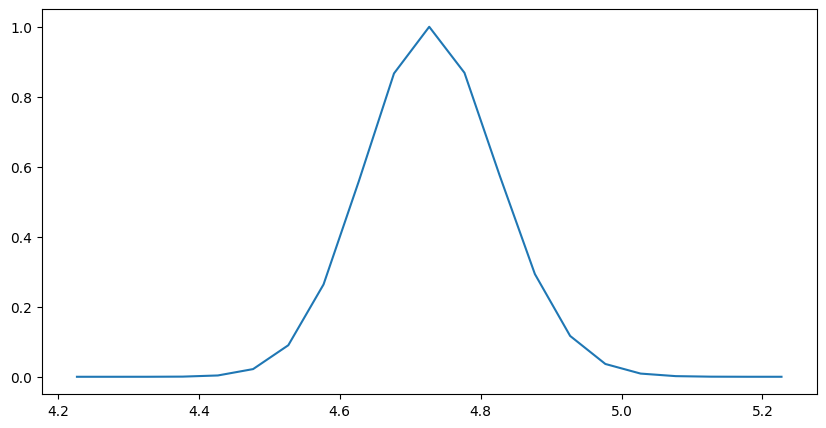

2D Search (Tau) for Part 13: 0it [00:00, ?it/s]

4.427007458024709 is a good enough tau
4.477007458024709 is a good enough tau
4.527007458024709 is a good enough tau
4.577007458024709 is a good enough tau
4.62700745802471 is a good enough tau
4.677007458024709 is a good enough tau
4.727007458024709 is a good enough tau
4.777007458024709 is a good enough tau
4.82700745802471 is a good enough tau
4.87700745802471 is a good enough tau
4.927007458024709 is a good enough tau
4.977007458024709 is a good enough tau
5.027007458024709 is a good enough tau
5.07700745802471 is a good enough tau
process_noise = 0.4541, measure_noise = 0.5532, ratio = 0.6532312703942207 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.2659395722726698, 
for a real g4 of 0.2605828109066728.


Tau grid for part 13:   0%|          | 0/21 [00:00<?, ?it/s]

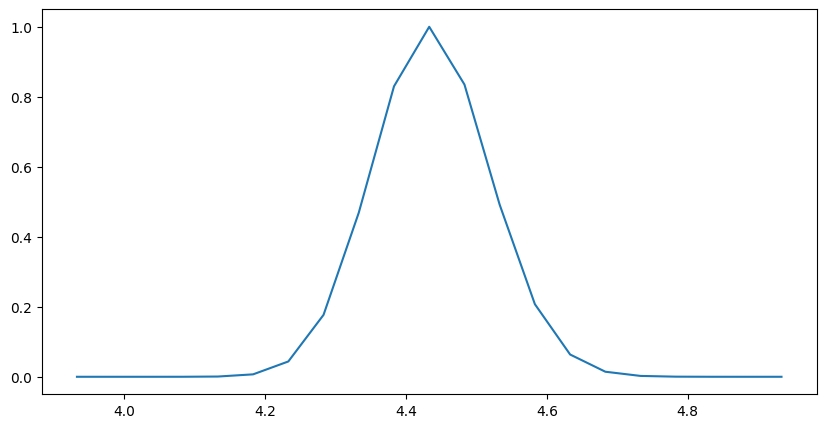

2D Search (Tau) for Part 13: 0it [00:00, ?it/s]

4.183052649878046 is a good enough tau
4.233052649878045 is a good enough tau
4.283052649878045 is a good enough tau
4.333052649878046 is a good enough tau
4.383052649878046 is a good enough tau
4.433052649878046 is a good enough tau
4.483052649878045 is a good enough tau
4.533052649878046 is a good enough tau
4.583052649878046 is a good enough tau
4.633052649878046 is a good enough tau
4.683052649878046 is a good enough tau
4.733052649878045 is a good enough tau
process_noise = 0.4483, measure_noise = 0.7914, ratio = 0.32219985094062337 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.38691855106163026, 
for a real g4 of 0.28483945265083155.


Tau grid for part 14:   0%|          | 0/21 [00:00<?, ?it/s]

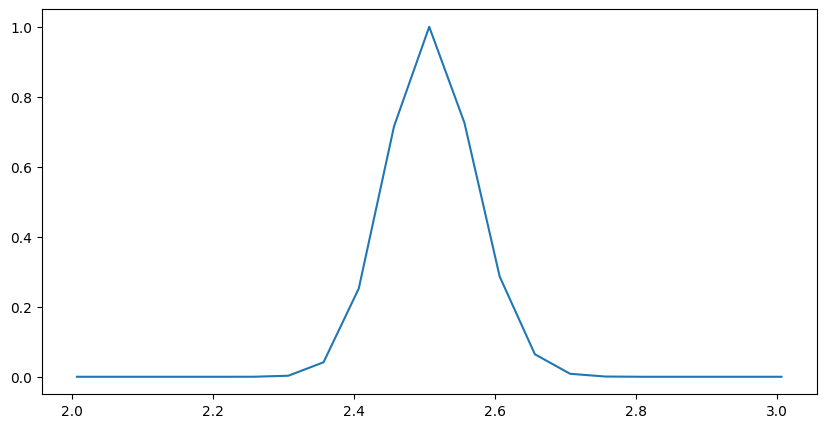

2D Search (Tau) for Part 14: 0it [00:00, ?it/s]

2.3069393353192584 is a good enough tau
2.3569393353192583 is a good enough tau
2.406939335319258 is a good enough tau
2.4569393353192583 is a good enough tau
2.506939335319258 is a good enough tau
2.5569393353192584 is a good enough tau
2.6069393353192583 is a good enough tau
2.656939335319258 is a good enough tau
2.7069393353192583 is a good enough tau
process_noise = 0.4483, measure_noise = 0.7117, ratio = 0.42622584120727647 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.2279434447340521, 
for a real g4 of 0.28483945265083155.


Tau grid for part 14:   0%|          | 0/21 [00:00<?, ?it/s]

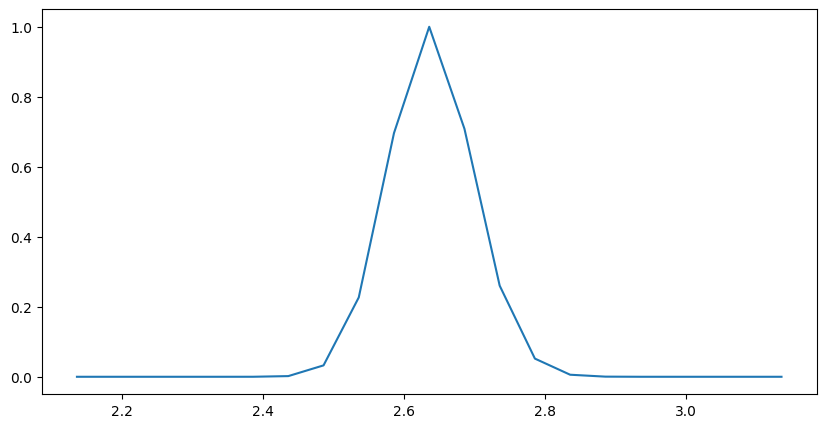

2D Search (Tau) for Part 14: 0it [00:00, ?it/s]

2.435828744502736 is a good enough tau
2.485828744502736 is a good enough tau
2.535828744502736 is a good enough tau
2.585828744502736 is a good enough tau
2.635828744502736 is a good enough tau
2.685828744502736 is a good enough tau
2.735828744502736 is a good enough tau
2.785828744502736 is a good enough tau
2.835828744502736 is a good enough tau
process_noise = 0.7222, measure_noise = 0.2286, ratio = 0.7860802159706396 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.23832721625845274, 
for a real g4 of 0.2668678457000755.


Tau grid for part 15:   0%|          | 0/21 [00:00<?, ?it/s]

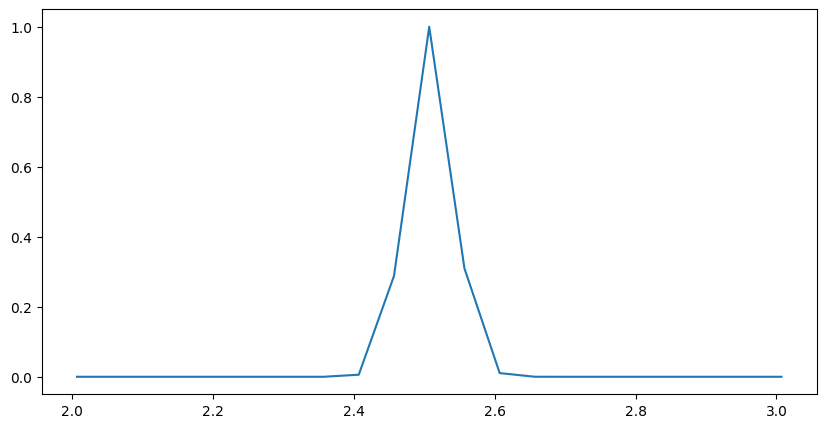

2D Search (Tau) for Part 15: 0it [00:00, ?it/s]

2.4071798901312356 is a good enough tau
2.457179890131236 is a good enough tau
2.5071798901312357 is a good enough tau
2.557179890131236 is a good enough tau
2.6071798901312357 is a good enough tau
process_noise = 0.7222, measure_noise = 0.2959, ratio = 0.9055968868484443 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.20365149919537068, 
for a real g4 of 0.2668678457000755.


Tau grid for part 15:   0%|          | 0/21 [00:00<?, ?it/s]

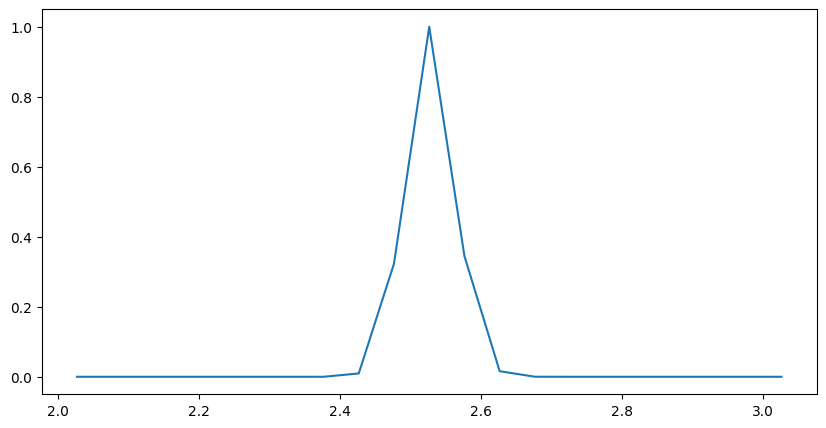

2D Search (Tau) for Part 15: 0it [00:00, ?it/s]

2.426679939052804 is a good enough tau
2.4766799390528043 is a good enough tau
2.526679939052804 is a good enough tau
2.576679939052804 is a good enough tau
2.626679939052804 is a good enough tau
process_noise = 0.6045, measure_noise = 0.2511, ratio = 0.7359128636892468 (like_passive)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.3276434423757199, 
for a real g4 of 0.3695012841716496.


Tau grid for part 16:   0%|          | 0/21 [00:00<?, ?it/s]

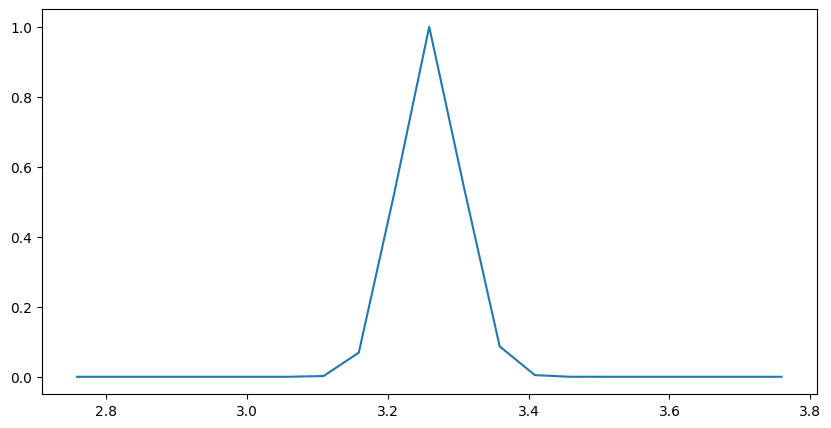

2D Search (Tau) for Part 16: 0it [00:00, ?it/s]

3.109013171302831 is a good enough tau
3.159013171302831 is a good enough tau
3.209013171302831 is a good enough tau
3.259013171302831 is a good enough tau
3.309013171302831 is a good enough tau
3.359013171302831 is a good enough tau
3.409013171302831 is a good enough tau
process_noise = 0.6045, measure_noise = 0.4552, ratio = 0.7715624278410027 (like_active)
Starts fitting simulated data..
Fitting done. Fitted g4 is 0.3664216435846682, 
for a real g4 of 0.3695012841716496.


Tau grid for part 16:   0%|          | 0/21 [00:00<?, ?it/s]

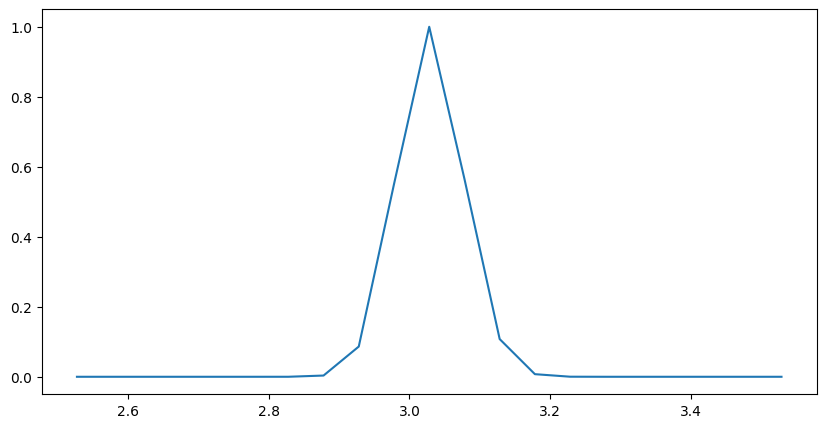

2D Search (Tau) for Part 16: 0it [00:00, ?it/s]

2.878092380687663 is a good enough tau
2.9280923806876626 is a good enough tau
2.978092380687663 is a good enough tau
3.0280923806876627 is a good enough tau
3.0780923806876626 is a good enough tau
3.128092380687663 is a good enough tau
3.1780923806876626 is a good enough tau
process_noise = 0.7589, measure_noise = 0.0703, ratio = 0.9195713104833994 (like_passive)
Starts fitting simulated data..


In [ ]:
task = "Active"
period = "late"
file_path = Path('MeasureNoiseControl')

# Define the summary path clearly and load existing progress 
summary_path = file_path / "metabifurc_control.csv"
if summary_path.exists():
    control_df = pd.read_csv(summary_path)
    print(f"Found existing summary at {summary_path}, containing {len(control_df)} entries.")
else:
    control_df = pd.DataFrame(columns=["probability_of_bifurcation", "metastability_score", "measure_noise", "process_noise", 
                                       "fitted_g4", "part", "noise_condition"])


# Fix the participant, and modulate the measurement noise VS process noise ratio
n_categories = 6
categories = list(range(n_categories))


for fake_part in tqdm(range(8, 100), desc="Participants"):

    part = fake_part % 20  # Use modulo to cycle through 20 participants

    for noise_condition in ['like_passive', 'like_active']:

        ############### DATA SIMULATION ###############

        # --- Load Parent Parameters in report & no-report---
        gainmodul_true = lead.model.StratifiedGainModulation(
            tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
        param_path = Path(f'Fit_Active_late') / f"GainModulatedModel_part{part}_params"
        gainmodul_true.load_params(param_path)

        gainmodul_true_passive = lead.model.StratifiedGainModulation(
                tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
        passive_params_path = Path(f'Fit_Passive_late') / f"GainModulatedModel_part{part}_params"
        gainmodul_true_passive.load_params(passive_params_path)

        # active noise ratio 
        sp_active, sm_active, tau_active = gainmodul_true.process_noise, gainmodul_true.measure_noise, gainmodul_true.tau
        Vp_active = sp_active**2 * tau_active**2 / (2*tau_active - 1)
        R_active = Vp_active / (Vp_active + sm_active**2)

        # passive noise ratio 
        sp_passive, sm_passive, tau_passive = gainmodul_true_passive.process_noise, gainmodul_true_passive.measure_noise, gainmodul_true_passive.tau
        Vp_passive = sp_passive**2 * tau_passive**2 / (2*tau_passive - 1)
        R_passive = Vp_passive / (Vp_passive + sm_passive**2)

        noise_ratio = R_active if noise_condition == 'like_active' else R_passive

        # --- Load Parent Parameters in report & no-report---
        if noise_condition == 'like_passive':
            sm_matched = Vp_active * (1 - R_passive) / R_passive
            gainmodul_true.set_params({'measure_noise': sm_matched})
        print(f'process_noise = {gainmodul_true.process_noise:.4f}, measure_noise = {gainmodul_true.measure_noise:.4f}, ratio = {noise_ratio} ({noise_condition})')

        # --- Input Definition ---
        one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(150)))
        input_train = {cat: np.stack([one_input for _ in range(150)]) for cat in categories} #around 150 trials per category

        # --- Data Simulation ---
        state_train = gainmodul_true.measure_simulations(input_series = input_train, initial_states = None)


        ############### FIT GAIN MODULATION MODEL ###############

        print('Starts fitting simulated data..')

        # Calibrate for fitting
        state_train_fit, input_train_fit = state_train.copy(), input_train.copy()
        no_stim_sliced = np.concatenate([state_train_fit[0][:, i*50:(i+1)*50] for i in range(5)])
        pre_stim_sliced = np.concatenate([state_train_fit[cat][:, :50] for cat in range(1, n_categories)])
        state_train_fit[0] = np.concatenate((no_stim_sliced, pre_stim_sliced))
        input_train_fit[0] = np.zeros_like(state_train_fit[0])

        # Fit linear then gainmodul 
        linear = lead.fitting_tools.clever_fit_linear(state_train = state_train_fit, input_train = input_train_fit, input_start_index=75, input_stop_index=100)
        gainmodul_parent = lead.fitting_tools.clever_fit_gainmodul(linear_prefitted = linear, state_train = state_train_fit, input_train = input_train_fit, n_loops = 2, input_start_index=75, input_stop_index=100)

        print(f"Fitting done. Fitted g4 is {getattr(gainmodul_parent, 'g4')}, \nfor a real g4 of {getattr(gainmodul_true, 'g4')}.")

        ############### USUAL BIF / METASCORE ANALYSIS (2D GRID SEARCH) ###############

        # --- Data Reformating ---
        state_train_constant_stim = {cat: state_train[cat][:,75:100] for cat in range(1, n_categories)}
        input_train_constant_stim = {cat: input_train[cat][:,75:100] for cat in range(1, n_categories)}
        no_stim_sliced = np.concatenate([state_train[0][:, i*50:(i+1)*50] for i in range(5)])
        pre_stim_sliced = np.concatenate([state_train[cat][:, :50] for cat in range(1, n_categories)])
        state_train_constant_stim[0] = np.concatenate((no_stim_sliced, pre_stim_sliced))
        input_train_constant_stim[0] = np.zeros_like(state_train_constant_stim[0])

        # --- Define Ranges ---
        thresh_range = np.linspace(0, 2, 21)
        max_threshold = np.percentile(state_train[n_categories-1], 90)
        if gainmodul_parent.tau < 2:
            tau_range = np.linspace(1.5, 2.5, 21)
        else:
            tau_range = np.linspace(gainmodul_parent.tau - 0.5, gainmodul_parent.tau + 0.5, 21)

        
        # --- Step 1: Grid Search for Tau (to fix input params for the next step) ---
        
        ll_list_tau, params_through_tau = [], []
        for tau in tqdm(tau_range, desc=f"Tau grid for part {part}"):
            linear_resting_state = lead.model.StratifiedLinear(tau=tau, process_noise=0.1, measure_noise=0.1, w0=0)
            
            linear_resting_state.fit(
                state_series={0: state_train_constant_stim[0]},
                input_series={0: input_train_constant_stim[0]},
                init_params=[tau, 0.1, 0.1] + [0]*7,
                bounds=[(1, 25), (0.01, 1), (0.01, 1)] + [(0, 1)]*7,
                fixed_params=['tau'] + [f'w{i}' for i in range(7)])
            
            ll_list_tau.append(linear_resting_state.loglikelihood({0: state_train_constant_stim[0]}, {0: input_train_constant_stim[0]}))
            params_through_tau.append([linear_resting_state.tau, linear_resting_state.process_noise, linear_resting_state.measure_noise])

        # Plot the distrib for visual check
        ll_array_tau = np.array(ll_list_tau)
        likelihood_tau = np.exp(ll_array_tau - np.max(ll_array_tau))
        plt.figure(figsize=(10,5))
        plt.plot(tau_range, likelihood_tau)
        plt.show()


        # --- Step 2: 2D Grid Search (Tau vs Threshold) ---
        bif_array, meta_array = np.zeros((len(tau_range), len(thresh_range))), np.zeros((len(tau_range), len(thresh_range)))
        ll_array = -np.inf*np.ones((len(tau_range), len(thresh_range)))

        # We iterate through the params found in Step 1
        for idx_tau, [tau, process_noise, measure_noise] in tqdm(enumerate(params_through_tau), desc=f"2D Search (Tau) for Part {part}"):

            # When tau is too unlikely, keep the default ll = -np.inf and bif = meta = 0 (no bifurcation)
            if likelihood_tau[idx_tau] < 0.001:
                continue
            print(f'{tau} is a good enough tau')

            ll_this_tau = ll_list_tau[idx_tau]

            # Inner loop over threshold
            for idx_th, threshold in enumerate(thresh_range):

                # When threshold is too high compared to data, keep the default ll = -np.inf and bif = meta = 0
                if threshold > max_threshold:
                    continue
                
                # A. Fit gain and input_weight for this specific (tau, threshold) combo
                ll_local = 0
                # Initialize base model for this grid point
                gainmodul = lead.model.StratifiedGainModulation(
                    tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                    threshold=threshold, sharpness=5)
                
                for cat in range(1, n_categories):
                    # Retrieve parent weights
                    w_parent = getattr(gainmodul_parent, f'w{cat}')
                    g_parent = getattr(gainmodul_parent, f'g{cat}')
                    
                    gainmodul_one_cat = lead.model.GainModulation(
                        tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                        threshold=threshold, sharpness=5, 
                        input_weight=w_parent, gain=g_parent)
                    
                    # Fit specific category
                    gainmodul_one_cat.fit(
                        state_series={0: state_train_constant_stim[cat]},
                        input_series={0: input_train_constant_stim[cat]},
                        init_params=[getattr(gainmodul_one_cat, pname) for pname in gainmodul_one_cat._param_names],
                        bounds=[(1,25), (0.01, 1), (0.01, 1), (0, 1), (0, 1), (0, 2), (0, 10)],
                        fixed_params=['tau', 'process_noise', 'measure_noise', 'threshold', 'sharpness'])
                    
                    ll_local += gainmodul_one_cat.loglikelihood({0: state_train_constant_stim[cat]}, {0: input_train_constant_stim[cat]})
                    
                    # Update the main stratified model with fitted params
                    gainmodul.set_params({f'w{cat}': gainmodul_one_cat.input_weight, f'g{cat}': gainmodul_one_cat.gain})
                
                ll_array[idx_tau, idx_th] = ll_this_tau + ll_local
                
                # B. Assess bifurcation and metastability (Linear Interpolation)
                states = np.linspace(-0.5, 3, 1000)
                delta_x_list = []
                max_metascore = 0
                
                for cat in range(n_categories - 1):
                    # Initial state diff
                    delta_x_list.append(gainmodul.core(state=states, input_value=1, signal_category=cat) - states)
                    
                    w1, g1 = getattr(gainmodul, f'w{cat}'), getattr(gainmodul, f'g{cat}')
                    w2, g2 = getattr(gainmodul, f'w{cat+1}'), getattr(gainmodul, f'g{cat+1}')
                    
                    # Travel on the (w1, g1) -> (w2, g2) segment 
                    for t in np.linspace(0, 1, 100):
                        w, g = w1 + t*(w2-w1), g1 + t*(g2-g1)
                        
                        interp_model = lead.model.GainModulation(
                            tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                            threshold=threshold, sharpness=5, 
                            input_weight=w, gain=g
                        )

                        # Prepare for metastability score calculation
                        model_func = interp_model.core
                        def f(states, input_value=0, signal_category=cat):
                            return model_func(states, input_value * np.ones_like(states), signal_category) - states
                        def df(states, input_value=0, signal_category=cat):
                            epsilon = 1e-5
                            return (f(states + epsilon, input_value, signal_category) - f(states - epsilon, input_value, signal_category)) / (2*epsilon)
            
                        # Compute metastability score
                        metascore = metastability_score(lambda x: f(x, input_value=1, signal_category=cat), 
                                                        lambda x: df(x, input_value=1, signal_category=cat), 
                                                        states, tau=tau)
                        max_metascore = max(max_metascore, metascore)

                        # Prepare for bifurcation check
                        delta_x_list.append(interp_model.core(state=states, input_value=1, signal_category=0) - states)

                # Compute bifurcation check
                bifbool = is_bifurcation(delta_x_list)
                bif_array[idx_tau, idx_th] = int(bifbool)
                meta_array[idx_tau, idx_th] = max_metascore



        # --- Process Results ---
        likelihood = np.exp(ll_array - np.max(ll_array))

        # Save Results
        os.makedirs(file_path, exist_ok=True)
        np.savez(file_path / f"2D_grid_search_simul{fake_part}.npz", threshold_range=thresh_range, tau_range=tau_range, 
                ll=ll_array, likelihood=likelihood, bifbool=bif_array, metascore=meta_array, 
                measure_noise=gainmodul_true.measure_noise, process_noise=gainmodul_true.process_noise, fitted_g4=getattr(gainmodul_parent, 'g4'),
                part=part, noise_condition=noise_condition)

        # Weighting BifProb and MetaScore over the 2D surface)
        bifprob = np.average(bif_array, weights=likelihood)
        metascore = np.average(meta_array, weights=likelihood)
        control_df.loc[len(control_df)] = [bifprob, metascore, gainmodul_true.measure_noise, gainmodul_true.process_noise, getattr(gainmodul_parent, 'g4'),
                                            fake_part, noise_condition]

        # Save summary CSV
        control_df.to_csv(file_path / f"metabifurc_control.csv", index=False)

        # --- 3. Plotting (2D Heatmap with Contours) ---
        plt.figure(figsize=(10, 8))
        
        # Create 2D Meshgrid for plotting
        # thresh_range (x-axis), tau_range (y-axis)
        X, Y = np.meshgrid(thresh_range, tau_range)
        
        # 1. Plot Heatmap of Likelihood
        # Using pcolormesh for the heatmap
        pcm = plt.pcolormesh(X, Y, likelihood, shading='auto', cmap='viridis')
        plt.colorbar(pcm, label='Relative Likelihood')
        
        # 2. Plot Contour of Bifurcation Boundary
        # We draw a line at 0.5 (since bif_array is 0 or 1) to show the border
        # colors='red' makes the bifurcation line distinct
        if np.any(bif_array) and not np.all(bif_array):
            CS = plt.contour(X, Y, bif_array, levels=[0.5], colors='red', linewidths=2)
            # Create a proxy artist for the legend
            from matplotlib.lines import Line2D
            proxy_line = Line2D([0], [0], color='red', linewidth=2, label='Bifurcation Boundary')
            plt.legend(handles=[proxy_line], loc='upper right')
        elif np.all(bif_array):
            plt.title(f"Part {fake_part} (All Bifurcation)")
        else:
            plt.title(f"Part {fake_part} (No Bifurcation)")

        plt.title(f'Parameter Space: Tau vs Threshold - Part {fake_part}\nWeighted Bifurcation Prob: {bifprob:.3f}')
        plt.xlabel('Threshold')
        plt.ylabel('Tau')
        
        # Save plot
        plt.savefig(file_path / f"2D_likelihood_simul{fake_part}.png")
        plt.close()

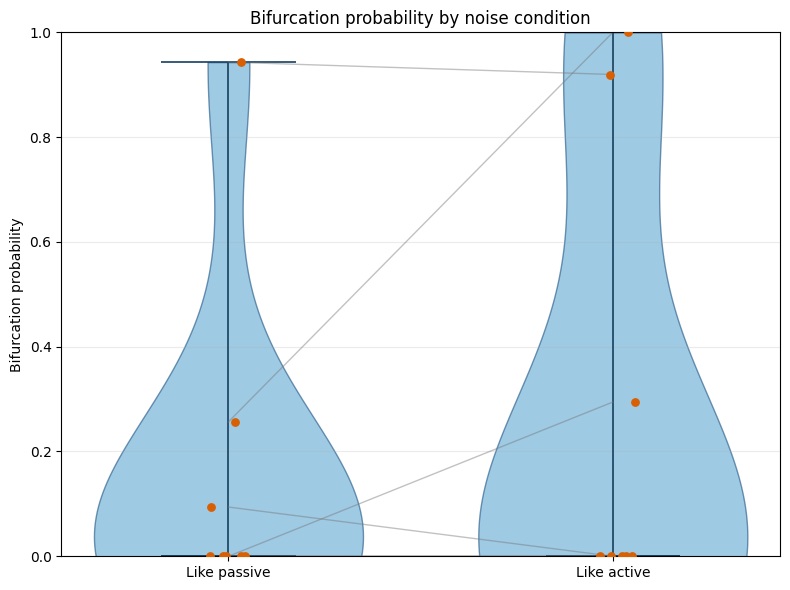

Paired participants: 8
Sign-flip permutation test for bifurcation probability: statistic=-0.115, p=0.438


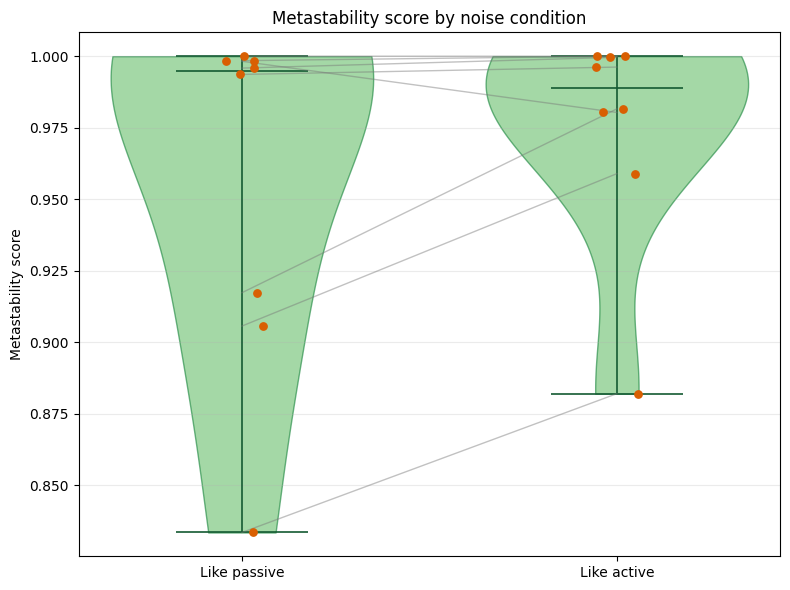

Sign-flip permutation test for metastability score: statistic=-0.0195, p=0.141


In [7]:
def sign_flip_permutation_test(x, y, n_resamples=20000, random_state=42):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.shape != y.shape:
        raise ValueError("x and y must be the same length.")
    diffs = x - y
    observed = diffs.mean()
    rng = np.random.default_rng(random_state)

    if len(diffs) == 0:
        return observed, 1.0

    # Exact enumeration is feasible for small paired samples; otherwise use Monte Carlo sign flips.
    if len(diffs) <= 12:
        signs = np.array(np.meshgrid(*([[-1.0, 1.0]] * len(diffs)), indexing="ij")).reshape(len(diffs), -1).T
        null_distribution = (signs * diffs).mean(axis=1)
        p_value = np.mean(np.abs(null_distribution) >= abs(observed))
        return observed, float(p_value)

    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_resamples, len(diffs)))
    null_distribution = (signs * diffs).mean(axis=1)
    p_value = np.mean(np.abs(null_distribution) >= abs(observed))
    return observed, float(p_value)


# Compare bifurcation probability and metastability between the two noise conditions
summary_path = Path("MeasureNoiseControl") / "metabifurc_control.csv"
comparison_df = pd.read_csv(summary_path)

required_columns = {"part", "noise_condition", "probability_of_bifurcation", "metastability_score"}
missing_columns = required_columns.difference(comparison_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in {summary_path}: {sorted(missing_columns)}")

comparison_df = comparison_df.dropna(subset=list(required_columns)).copy()
comparison_df["part"] = comparison_df["part"].astype(str)

# Keep the last result for each participant/condition in case the simulation cell was rerun.
comparison_df = comparison_df.drop_duplicates(
    subset=["part", "noise_condition"], keep="last"
)
paired_df = comparison_df.pivot(
    index="part", columns="noise_condition", values=["probability_of_bifurcation", "metastability_score"]
).dropna()

if len(paired_df) < 2:
    raise ValueError("At least two participants with both noise conditions are required.")

condition_labels = ["Like passive", "Like active"]
positions = np.array([1, 2])
rng = np.random.default_rng(42)

# Plot bifurcation probability.
passive_values = paired_df[("probability_of_bifurcation", "like_passive")].to_numpy()
active_values = paired_df[("probability_of_bifurcation", "like_active")].to_numpy()
bif_statistic, bif_p_value = sign_flip_permutation_test(passive_values, active_values, n_resamples=20000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
violins = ax.violinplot(
    [passive_values, active_values],
    positions=positions,
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=True,
)
for body in violins["bodies"]:
    body.set_facecolor("#6baed6")
    body.set_edgecolor("#2b5d8a")
    body.set_alpha(0.65)
for key in ("cmedians", "cmins", "cmaxes", "cbars"):
    violins[key].set_color("#173f5f")
    violins[key].set_linewidth(1.2)

for passive_value, active_value in zip(passive_values, active_values):
    ax.plot(positions, [passive_value, active_value], color="#777777", alpha=0.45, linewidth=1)
    jitter = rng.uniform(-0.06, 0.06, size=2)
    ax.scatter(positions + jitter, [passive_value, active_value], color="#d95f02", s=28, zorder=3)

ax.set_xticks(positions, condition_labels)
ax.set_ylabel("Bifurcation probability")
ax.set_ylim(0, 1)
ax.set_title("Bifurcation probability by noise condition")
ax.grid(axis="y", alpha=0.25)
# ax.text(
#     0.98,
#     0.98,
#     f"Sign-flip permutation test: p = {bif_p_value:.3g}\nn = {len(paired_df)} participants",
#     transform=ax.transAxes,
#     ha="right",
#     va="top",
#     bbox={"facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.9},
# )
fig.tight_layout()
plt.show()

print(f"Paired participants: {len(paired_df)}")
print(f"Sign-flip permutation test for bifurcation probability: statistic={bif_statistic:.3g}, p={bif_p_value:.3g}")

# Plot metastability score using the same paired participants.
meta_passive_values = paired_df[("metastability_score", "like_passive")].to_numpy()
meta_active_values = paired_df[("metastability_score", "like_active")].to_numpy()
meta_statistic, meta_p_value = sign_flip_permutation_test(meta_passive_values, meta_active_values, n_resamples=20000, random_state=42)

fig_meta, ax_meta = plt.subplots(figsize=(8, 6))
meta_violins = ax_meta.violinplot(
    [meta_passive_values, meta_active_values],
    positions=positions,
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=True,
)
for body in meta_violins["bodies"]:
    body.set_facecolor("#74c476")
    body.set_edgecolor("#238b45")
    body.set_alpha(0.65)
for key in ("cmedians", "cmins", "cmaxes", "cbars"):
    meta_violins[key].set_color("#145a32")
    meta_violins[key].set_linewidth(1.2)

for passive_value, active_value in zip(meta_passive_values, meta_active_values):
    ax_meta.plot(positions, [passive_value, active_value], color="#777777", alpha=0.45, linewidth=1)
    jitter = rng.uniform(-0.06, 0.06, size=2)
    ax_meta.scatter(positions + jitter, [passive_value, active_value], color="#d95f02", s=28, zorder=3)

ax_meta.set_xticks(positions, condition_labels)
ax_meta.set_ylabel("Metastability score")
ax_meta.set_title("Metastability score by noise condition")
ax_meta.grid(axis="y", alpha=0.25)
# ax_meta.text(
#     0.98,
#     0.98,
#     f"Sign-flip permutation test: p = {meta_p_value:.3g}\nn = {len(paired_df)} participants",
#     transform=ax_meta.transAxes,
#     ha="right",
#     va="top",
#     bbox={"facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.9},
# )
fig_meta.tight_layout()
plt.show()

print(f"Sign-flip permutation test for metastability score: statistic={meta_statistic:.3g}, p={meta_p_value:.3g}")

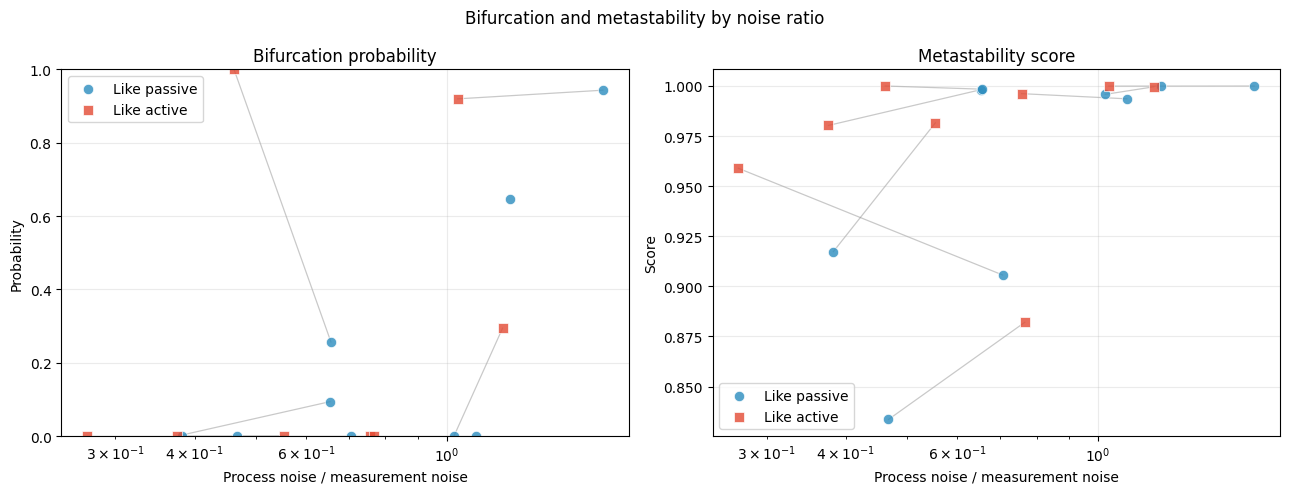

In [8]:
# Plot bifurcation probability and metastability as functions of the process-to-measurement noise ratio.
plot_columns = {
    "process_noise",
    "measure_noise",
    "probability_of_bifurcation",
    "metastability_score",
    "noise_condition",
}
missing_plot_columns = plot_columns.difference(comparison_df.columns)
if missing_plot_columns:
    raise ValueError(f"Missing required columns for noise-ratio plot: {sorted(missing_plot_columns)}")

ratio_df = comparison_df.copy()
ratio_df["noise_ratio"] = ratio_df["process_noise"] / ratio_df["measure_noise"]
ratio_df = ratio_df.replace([np.inf, -np.inf], np.nan).dropna(subset=list(plot_columns | {"noise_ratio"}))
ratio_df = ratio_df[ratio_df["noise_ratio"] > 0]

condition_styles = {
    "like_passive": {"label": "Like passive", "color": "#2b8cbe", "marker": "o"},
    "like_active": {"label": "Like active", "color": "#e34a33", "marker": "s"},
}
fig_ratio, axes_ratio = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

# Connect the two condition-specific observations belonging to each participant.
for _, participant_df in ratio_df.groupby("part"):
    participant_df = participant_df.set_index("noise_condition")
    if not {"like_passive", "like_active"}.issubset(participant_df.index):
        continue
    paired_conditions = participant_df.loc[["like_passive", "like_active"]]
    axes_ratio[0].plot(
        paired_conditions["noise_ratio"],
        paired_conditions["probability_of_bifurcation"],
        color="#888888",
        alpha=0.45,
        linewidth=0.9,
        zorder=1,
    )
    axes_ratio[1].plot(
        paired_conditions["noise_ratio"],
        paired_conditions["metastability_score"],
        color="#888888",
        alpha=0.45,
        linewidth=0.9,
        zorder=1,
    )

for condition, style in condition_styles.items():
    condition_df = ratio_df[ratio_df["noise_condition"] == condition]
    if condition_df.empty:
        continue
    axes_ratio[0].scatter(
        condition_df["noise_ratio"],
        condition_df["probability_of_bifurcation"],
        label=style["label"],
        color=style["color"],
        marker=style["marker"],
        alpha=0.8,
        edgecolors="white",
        linewidths=0.6,
        s=55,
        zorder=2,
    )
    axes_ratio[1].scatter(
        condition_df["noise_ratio"],
        condition_df["metastability_score"],
        label=style["label"],
        color=style["color"],
        marker=style["marker"],
        alpha=0.8,
        edgecolors="white",
        linewidths=0.6,
        s=55,
        zorder=2,
    )

axes_ratio[0].set_title("Bifurcation probability")
axes_ratio[0].set_ylabel("Probability")
axes_ratio[0].set_ylim(0, 1)
axes_ratio[1].set_title("Metastability score")
axes_ratio[1].set_ylabel("Score")
for axis in axes_ratio:
    axis.set_xlabel("Process noise / measurement noise")
    axis.set_xscale("log")
    axis.grid(True, axis="both", alpha=0.25)
    axis.legend()

fig_ratio.suptitle("Bifurcation and metastability by noise ratio")
fig_ratio.tight_layout()
plt.show()